In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix

import kagglehub

c:\Users\Shivam\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Download dataset
path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

print("Path:", path)

# Check files
print(os.listdir(path))

# Dataset path
dataset_path = os.path.join(path, "EuroSAT")

Download already complete (2194656567 bytes).
Extracting files...
Path: C:\Users\Shivam\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6
['EuroSAT', 'EuroSATallBands']


In [4]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,

    zoom_range=0.2,
    horizontal_flip=True
)

In [5]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.


In [6]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

# Freeze most layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(10, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',

    patience=3,

    restore_best_weights=True
)

In [9]:
history = model.fit(
    train_data,

    validation_data=val_data,

    epochs=10,

    callbacks=[early_stop]
)

Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 111s 157ms/step - accuracy: 0.8083 - loss: 0.5939 - val_accuracy: 0.7426 - val_loss: 0.8045
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 140s 208ms/step - accuracy: 0.8813 - loss: 0.3552 - val_accuracy: 0.6967 - val_loss: 1.1046
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 174s 255ms/step - accuracy: 0.8998 - loss: 0.3040 - val_accuracy: 0.8561 - val_loss: 0.4348
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 149s 221ms/step - accuracy: 0.9072 - loss: 0.2719 - val_accuracy: 0.8157 - val_loss: 0.5917
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 149s 221ms/step - accuracy: 0.9199 - loss: 0.2455 - val_accuracy: 0.8807 - val_loss: 0.3740
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 112s 167ms/step - accuracy: 0.9224 - loss: 0.2306 - val_accuracy: 0.8946 - val_loss: 0.3276
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 631s 937ms/step - accuracy: 0.9250 - loss: 0.2263 - val_accuracy: 0.8874 - val_loss: 0.3317
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 667s 987ms/step - accuracy: 0.9312 -

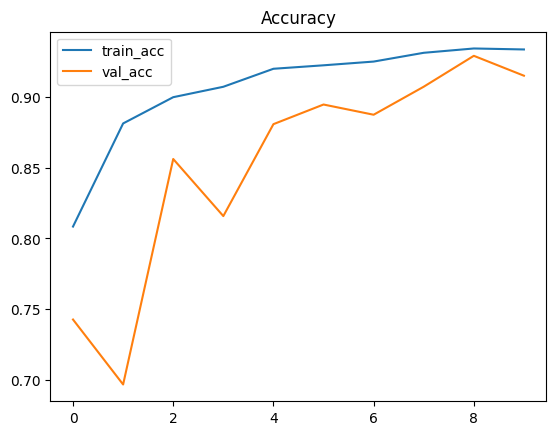

In [10]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')

plt.legend()

plt.title("Accuracy")

plt.savefig("accuracy_plot.png")

plt.show()

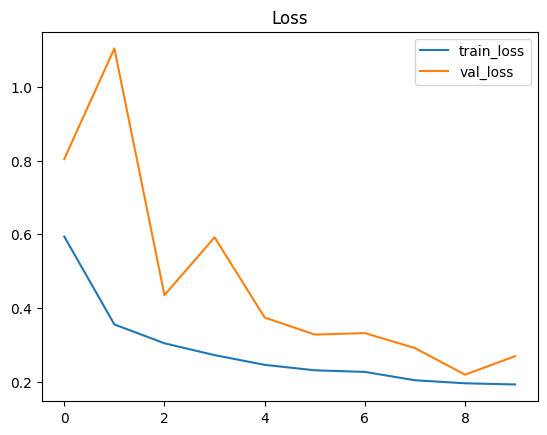

In [11]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')

plt.legend()

plt.title("Loss")

plt.savefig("loss_plot.png")

plt.show()

In [12]:
best_val_acc = max(history.history['val_accuracy'])

best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1

print("Best Validation Accuracy:", best_val_acc)

print("Best Epoch:", best_epoch)

Best Validation Accuracy: 0.9290740489959717
Best Epoch: 9


169/169 ━━━━━━━━━━━━━━━━━━━━ 18s 104ms/step


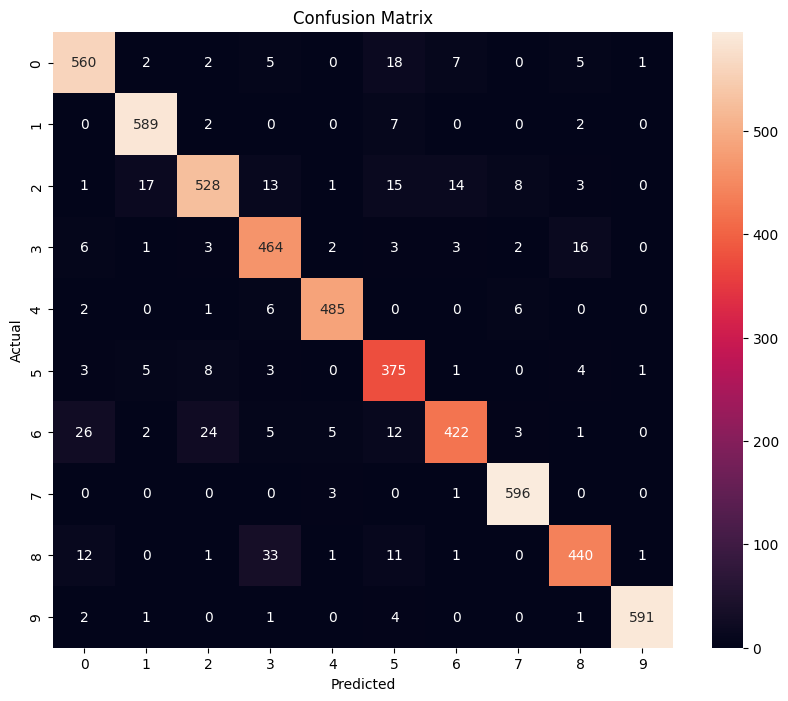

In [13]:
y_pred = model.predict(val_data)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")

plt.show()

Now that we have a valid image path, let's modify the prediction cell to use this image.

Sample Image: C:\Users\Shivam\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\AnnualCrop\AnnualCrop_1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step


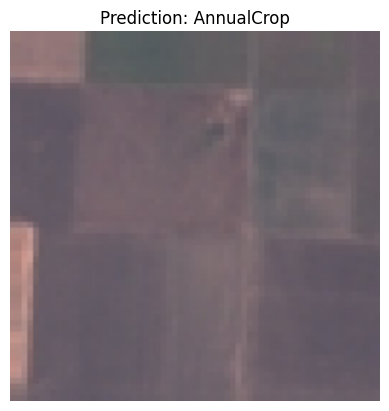

Confidence: 0.6943417


In [14]:
# Get class directories
class_dirs = os.listdir(dataset_path)

# Choose first class
first_class_dir = os.path.join(dataset_path, class_dirs[0])

# Get image list
image_files = os.listdir(first_class_dir)

# Select sample image
sample_image_path = os.path.join(first_class_dir, image_files[0])

print("Sample Image:", sample_image_path)

# Load image
img = image.load_img(sample_image_path, target_size=(128,128))

# Convert image
img_array = image.img_to_array(img) / 255.0

img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

confidence = np.max(prediction)

# Class labels
class_labels = train_data.class_indices

class_labels = {v:k for k,v in class_labels.items()}

# Display image
plt.imshow(img)

plt.title(f"Prediction: {class_labels[predicted_class]}")

plt.axis('off')

plt.savefig("sample_prediction.png")

plt.show()

print("Confidence:", confidence)

In [15]:
model.save("eurosat_model.keras")